# Analisis Exploratorio de Datos

Vamos a buscar entender mejor los datos y responder algunas preguntas:
- Hay relacion entre el precio y las reviews?
- Hay relacion entre la fama y las reviews?
- Hay relacion entre el precio y la fama?
- Hay juegos muy buenos y baratos? O juegos muy caros y malos?

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [40]:
df = pd.read_csv('../data/dataset.csv')

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3816 entries, 0 to 3815
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   appid              3816 non-null   int64  
 1   name               3816 non-null   str    
 2   msrp               3816 non-null   float64
 3   release_ts         3806 non-null   float64
 4   n_weeks            3816 non-null   int64  
 5   is_free            3816 non-null   bool   
 6   total_positive     3816 non-null   int64  
 7   total_negative     3816 non-null   int64  
 8   total_reviews      3816 non-null   int64  
 9   review_score_desc  3816 non-null   str    
 10  reviews_ratio      3816 non-null   float64
 11  release_date       3806 non-null   str    
 12  age_days           3806 non-null   float64
 13  bucket             3816 non-null   str    
dtypes: bool(1), float64(4), int64(5), str(4)
memory usage: 391.4 KB


Estudiamos las distribuciones de las features que tenemos, como msrp, reviews_ratio, n_weeks, etc

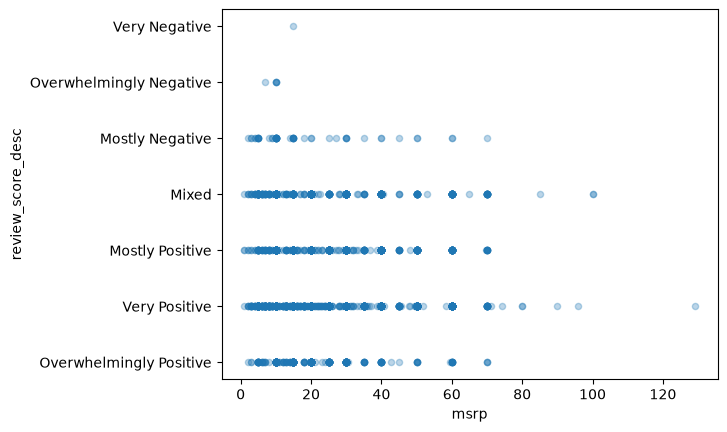

In [42]:
df.plot.scatter('msrp', 'review_score_desc', alpha=0.3)
plt.savefig('../img/msrp-review_score.png')
plt.show()

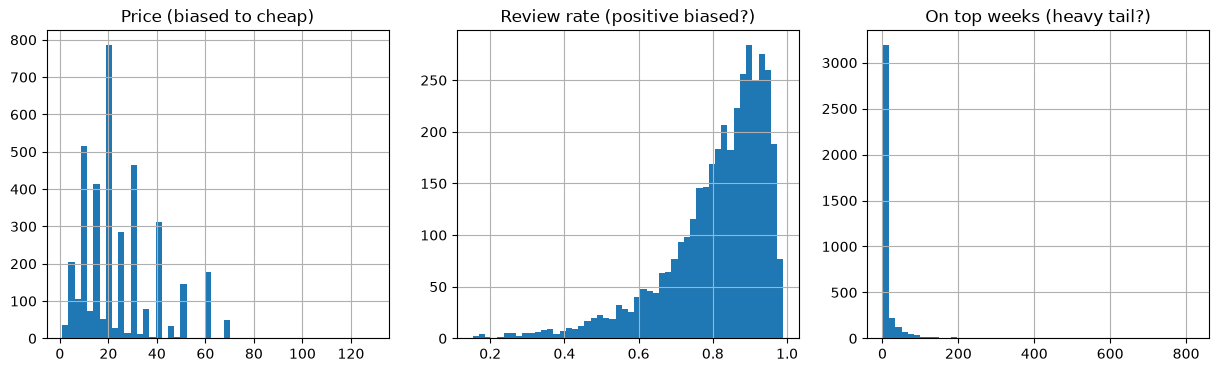

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(15,  4))
df['msrp'].hist(bins=50, ax=ax[0])
ax[0].set_title('Price (biased to cheap)')
df['reviews_ratio'].hist(bins=50, ax=ax[1])
ax[1].set_title('Review rate (positive biased?)')
df['n_weeks'].hist(bins=50, ax=ax[2])
ax[2].set_title('On top weeks (heavy tail?)')
plt.savefig('../img/dist.png')
plt.show()

Ahora buscamos estudiar la pregunta principal: los juegos caros tienen mejores reviews?

En el scatter a simple vista no se ve una correlacion muy marcada, lo cual afirmamos al calcular las correlacines de Pearson y Spearman

Finalmente en el boxplot de `reviews_ratio` y `bucket` (separaciones por precios) podemos notar leves diferencias entre las reviews segun precios. Los juegos mas baratos tienden a concentrar sus reviews entre 0.8 y 0.9, aunque tambien tienen mas outliers. Hay que tener cuidado, porque esto puede ser consecuencia de la diferencia de cantidad de juegos por cada precio

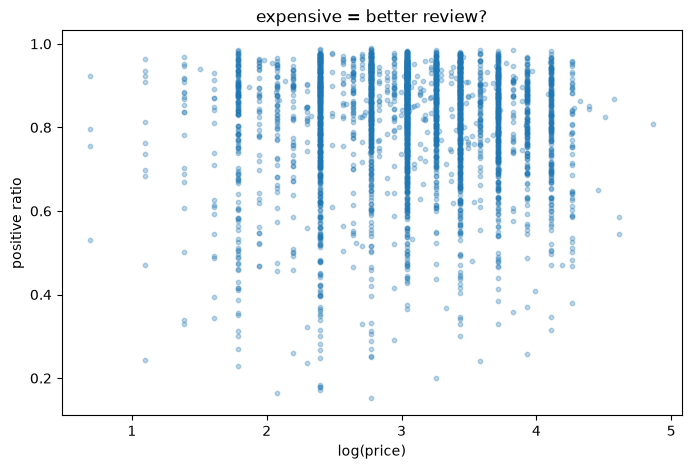

In [44]:
plt.figure(figsize=(8, 5))
plt.scatter(np.log1p(df['msrp']), df['reviews_ratio'], alpha=0.3, s=10)
plt.xlabel('log(price)')
plt.ylabel('positive ratio')
plt.title('expensive = better review?')
plt.savefig('../img/expensive-equal-better.png')
plt.show()

<Figure size 1000x500 with 0 Axes>

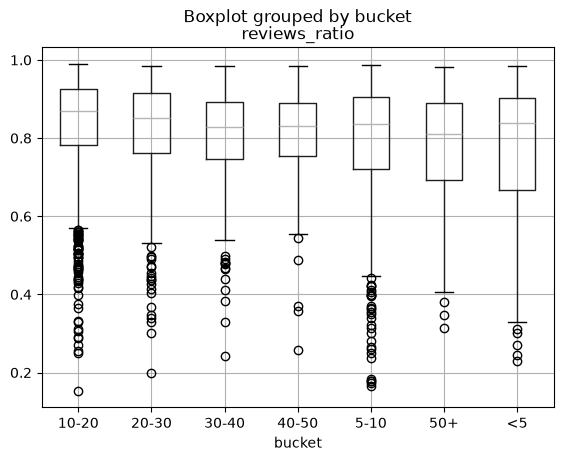

In [45]:
plt.figure(figsize=(10, 5))
df.boxplot('reviews_ratio', by='bucket')
plt.savefig('../img/bucket-reviews.png')
plt.show()

In [46]:
print('Pearson: ', df[['msrp', 'reviews_ratio']].corr().iloc[0,1].round(3))
print('Spearman: ', df[['msrp', 'reviews_ratio']].corr(method='spearman').iloc[0,1].round(3))

Pearson:  -0.018
Spearman:  -0.038


Al scater visto previamente, que grafica la relacion entre el `msrp` y `reviews_ratio`, le adiccionamos una escala segun la cantidad de semanas en el top. Se puede notar muchos juegos caros, son los que mas estuvieron en el top , o que hay variedad de juegos caros que mantienen posiciones mas altas en la escala de `reviews_ratio`

Claramente, esto no son resultados, puesto que debemos verificar que realmente se comporten asi los datos. Recordemos que estamos en una etapa de analisis exploratorio 

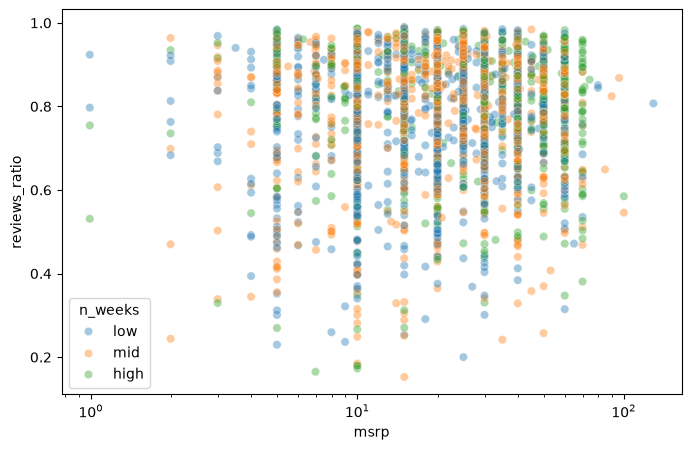

In [47]:
fame_bucket = pd.qcut(
    df['n_weeks'].rank(method='first'),
    q=3,
    labels=['low', 'mid', 'high']
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='msrp',
    y='reviews_ratio',
    hue=fame_bucket,
    alpha=0.4
)
plt.xscale('log')
plt.savefig('../img/n_weeks-ratio.png')
plt.show()

Tambien buscamos estudiar los outliers, ya que puede ser interesante ver juegos muy caros con malas reviews, o juegos muy buenos pero muy baratos.

Se da el caso que algunos juegos que encabezan la lista de precios son en realidad bundles (paquetes de juegos, DLCs, etc) puestos en venta en Steam, por lo que hay que analizar con cautela los mismos

In [48]:
print('Expensive and bad')
print(df.nlargest(10, 'msrp')[['name', 'msrp', 'reviews_ratio', 'n_weeks']])

print('Cheap and good')
print(df[df['msrp'] <= 10].nlargest(10, 'reviews_ratio')[['name', 'msrp', 'reviews_ratio', 'n_weeks']])

print('The best and worst of each bucket')
print(df.loc[df.groupby('bucket')['reviews_ratio'].idxmax()][['name', 'msrp', 'reviews_ratio', 'bucket']])

Expensive and bad
                                        name    msrp  reviews_ratio  n_weeks
2529                     Yakuza 3 Remastered  129.13       0.807195        1
3566                           Borderlands 4   99.99       0.584962       24
3727                                WWE 2K26   99.99       0.545844        3
3299                          Fishing Planet   95.97       0.868125        3
1769  THE KING OF FIGHTERS XIV STEAM EDITION   89.99       0.824408        5
3389     SWORD ART ONLINE Fractured Daydream   84.99       0.649037        3
2314              Command: Modern Operations   79.99       0.850920        1
3421      Taiko no Tatsujin: Rhythm Festival   79.99       0.844501        1
2422                             The Sims™ 4   74.37       0.863953      305
1648                              Battlerite   71.22       0.847045       38
Cheap and good
                                 name  msrp  reviews_ratio  n_weeks
388                          Portal 2  9.99       0.

Ahora buscamos responder o al menos estudiar algunas preguntas que pueden resultar interesantes, de las cuales podemos sacar algo de informacion extra para estudiar los resultados

In [49]:
# La mediana cambia con el precio?
print(df.groupby('bucket', observed=True)['reviews_ratio'].agg(['median','mean','count']).round(3))
print('-----')

# La fama explica lo que el precio no?
df['fame'] = fame_bucket
print(df.groupby('fame', observed=True)['reviews_ratio'].agg(['median','count']).round(3))
print('-----')

# Los peores de cada bucket
print(df.loc[df.groupby('bucket', observed=True)['reviews_ratio'].idxmin()][['name','msrp','reviews_ratio','n_weeks']])
print('-----')

# Precio y fama correlacionan?
print('Correlacion entre fama y precio: ', df[['msrp','n_weeks']].corr(method='spearman').iloc[0,1].round(3))


        median   mean  count
bucket                      
10-20    0.868  0.833   1324
20-30    0.851  0.824    797
30-40    0.828  0.807    408
40-50    0.831  0.808    188
5-10     0.835  0.791    652
50+      0.811  0.782    243
<5       0.839  0.765    204
-----
      median  count
fame               
low    0.823   1272
mid    0.843   1272
high   0.873   1272
-----
                                             name   msrp  reviews_ratio  \
880                                      Citadels  14.99       0.152439   
1190                       Lords of the Black Sun  24.99       0.200000   
3226   STAR WARS™: Battlefront Classic Collection  35.01       0.241601   
2997                       Kerbal Space Program 2  49.99       0.257227   
162        Command & Conquer™ 4 Tiberian Twilight   6.96       0.165039   
2154                                  LEFT ALIVE™  59.99       0.314754   
862   Agricultural Simulator 2013 - Steam Edition   4.99       0.229730   

      n_weeks  
880       

## Conclusiones preliminares

- Si bien son muy similares, parece haber una diferencia entre las reviews de juegos baratos y caros
- Hay outliers interesantes para analizar individualmente. Juegos baratos muy buenos, o juegos caros malos
- Puede estar influyendo algun sesgo psicologico a la hora de puntuar juegos caros